### generates plots for cmip comparison

In [1]:
import ewatercycle.forcing
import matplotlib.pyplot as plt
import xarray as xr
from pathlib import Path
import dask

/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


In [2]:
#list_models = ["MIROC6", "NorESM2-LM", "CanESM5", "FGOALS-g3", "MPI-ESM1-2-HR", "MRI-ESM2-0"]
list_models = ["MIROC6", "MPI-ESM1-2-HR", "MRI-ESM2-0", "CanESM5"]

ERA_5_location = Path("/home/avandervee3/aral_sea_full_project/data/forcing/ERA5/raw/1940-2020/AralSea_basin/work/diagnostic/script")
# cmip_root = Path("/home/avandervee3/complete_pcrglob_run/data/forcing/output/PCRGLOBWB/CMIP_historical_copy")

# cmip_locations = {
#     model: cmip_root / f"CMIP6_{model}_1940-2014/AralSea_basin/work/diagnostic/script"
#     for model in list_models
# }

# cmip_forcings = {
#     model: ewatercycle.forcing.sources["PCRGlobWBForcing"].load(directory=location)
#     for model, location in cmip_locations.items()
# }

#CMIP6_historical_MIROC6_location = cmip_locations["MIROC6"]



In [3]:

cmip_root_hist_bc = Path("/home/avandervee3/aral_sea_full_project/data/forcing/CMIP6/historical/bias_corrected")
cmip_root_hist_copy = Path("/home/avandervee3/aral_sea_full_project/data/forcing/CMIP6/historical/regridded")


cmip_locations_hist_copy = {
    model: cmip_root_hist_copy / f"{model}/r1i1p1f1/1940-2014/AralSea_basin/work/diagnostic/script"
    for model in list_models
}

cmip_forcings_hist_copy = {
    model: ewatercycle.forcing.sources["PCRGlobWBForcing"].load(directory=location)
    for model, location in cmip_locations_hist_copy.items()
}

cmip_locations_hist_bc = {
    model: cmip_root_hist_bc / f"{model}/r1i1p1f1/1940-2014/AralSea_basin/work/diagnostic/script"
    for model in list_models
}

cmip_forcings_hist_bc = {
    model: ewatercycle.forcing.sources["PCRGlobWBForcing"].load(directory=location)
    for model, location in cmip_locations_hist_bc.items()
}



In [4]:
ERA5_forcing = ewatercycle.forcing.sources["PCRGlobWBForcing"].load(directory=ERA_5_location)

selected_forcings = {
    "ERA5": ERA5_forcing,
    **{f"{model} raw": forcing for model, forcing in cmip_forcings_hist_copy.items()},
    **{f"{model} corrected": forcing for model, forcing in cmip_forcings_hist_bc.items()},
}



In [5]:
selected_forcings

{'ERA5': PCRGlobWBForcing(start_time='1940-01-01T00:00:00Z', end_time='2020-12-31T00:00:00Z', directory=PosixPath('/home/avandervee3/aral_sea_full_project/data/forcing/ERA5/raw/1940-2020/AralSea_basin/work/diagnostic/script'), shape=PosixPath('/home/avandervee3/aral_sea_full_project/data/forcing/ERA5/raw/1940-2020/AralSea_basin/work/diagnostic/script/AralSea_basin.shp'), filenames={}, precipitationNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_pr_1940-2020_AralSea_basin.nc', temperatureNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_tas_1940-2020_AralSea_basin.nc'),
 'MIROC6 raw': PCRGlobWBForcing(start_time='1940-01-01T00:00:00Z', end_time='2014-12-31T00:00:00Z', directory=PosixPath('/home/avandervee3/aral_sea_full_project/data/forcing/CMIP6/historical/regridded/MIROC6/r1i1p1f1/1940-2014/AralSea_basin/work/diagnostic/script'), shape=PosixPath('/home/avandervee3/aral_sea_full_project/data/forcing/CMIP6/historical/regridded/MIROC6/r1i1p1f1/1940-2014/AralSea_basin/work/diagnostic/script/AralSea_basin.shp')

In [6]:
ERA5_forcing

PCRGlobWBForcing(start_time='1940-01-01T00:00:00Z', end_time='2020-12-31T00:00:00Z', directory=PosixPath('/home/avandervee3/aral_sea_full_project/data/forcing/ERA5/raw/1940-2020/AralSea_basin/work/diagnostic/script'), shape=PosixPath('/home/avandervee3/aral_sea_full_project/data/forcing/ERA5/raw/1940-2020/AralSea_basin/work/diagnostic/script/AralSea_basin.shp'), filenames={}, precipitationNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_pr_1940-2020_AralSea_basin.nc', temperatureNC='pcrglobwb_OBS6_ERA5_reanaly_1_day_tas_1940-2020_AralSea_basin.nc')

In [ ]:
forcing_paths = {
    name: {
        "precip": forcing.directory / forcing.precipitationNC,
        "tas": forcing.directory / forcing.temperatureNC,
    }
    for name, forcing in selected_forcings.items()
}

cmap = plt.get_cmap("tab10") 

cmip_styles = {

    "MIROC6": {"color": cmap(1), "linewidth": 1.15},

    "NorESM2-LM": {"color": cmap(2), "linewidth": 1.15},

    "CanESM5": {"color": cmap(3), "linewidth": 1.15},

    "FGOALS-g3": {"color": cmap(4), "linewidth": 1.15},

    "MPI-ESM1-2-HR": {"color": cmap(2), "linewidth": 1.15},

    "MRI-ESM2-0": {"color": cmap(3), "linewidth": 1.15},

}

In [8]:
# chunks = {"time": -1, "lat": 20, "lon": 20} 

# datasets = {
#     name: {
#         "pr_ds": xr.open_dataset(paths["precip"], chunks=chunks),
#         "tas_ds": xr.open_dataset(paths["tas"], chunks=chunks),
#     }
#     for name, paths in forcing_paths.items()
# }

# load_cmip_hist_bias_pr = xr.open_dataset(cmip_hist_bias_pr_path, chunks=chunks)
# load_cmip_hist_bias_tas = xr.open_dataset(cmip_hist_bias_tas_path, chunks=chunks)


In [13]:

def pick_var(ds, preferred):
    return preferred if preferred in ds.data_vars else list(ds.data_vars)[0]

def basin_daily_series(ds, var_name):
    da = ds[var_name]
    spatial_dims = [d for d in da.dims if d != "time"]
    if spatial_dims:
        da = da.mean(dim=spatial_dims)
    return da

# Set up styles
cmap = plt.get_cmap("tab10")
cmip_styles = {
    "MIROC6": {"color": cmap(1), "linewidth": 1.15},
    "NorESM2-LM": {"color": cmap(2), "linewidth": 1.15},
    "CanESM5": {"color": cmap(3), "linewidth": 1.15},
    "FGOALS-g3": {"color": cmap(4), "linewidth": 1.15},
    "MPI-ESM1-2-HR": {"color": cmap(2), "linewidth": 1.15},
    "MRI-ESM2-0": {"color": cmap(3), "linewidth": 1.15},
}

# =======================================================
# 1. LOAD DATASETS FIRST (With optimized "time": -1 chunking)
# =======================================================
chunks = {"time": -1, "lat": 20, "lon": 20}

datasets = {
    name: {
        "pr_ds": xr.open_dataset(paths["precip"], chunks=chunks),
        "tas_ds": xr.open_dataset(paths["tas"], chunks=chunks),
    }
    for name, paths in forcing_paths.items()
}

load_precip = datasets["ERA5"]["pr_ds"]
load_temp = datasets["ERA5"]["tas_ds"]


# =======================================================
# 2. BUILD THE EXPERIMENTS DICTIONARY
# =======================================================
experiments = {
    "ERA5": {
        "pr_ds": load_precip,
        "tas_ds": load_temp,
        "color": "black",
        "linestyle": "-",
        "linewidth": 2,
    },
    **{
        f"CMIP historical {model}": {
            "pr_ds": datasets[f"{model} raw"]["pr_ds"],
            "tas_ds": datasets[f"{model} raw"]["tas_ds"],
            **cmip_styles[model],
            "linestyle": ":",
        }
        for model in list_models
    },
    **{
        f"CMIP corrected {model}": {
            "pr_ds": datasets[f"{model} corrected"]["pr_ds"],
            "tas_ds": datasets[f"{model} corrected"]["tas_ds"],
            **cmip_styles[model],
            "linestyle": "-",
        }
        for model in list_models
    },
}


# =======================================================
# 3. BUILD BASIN-MEAN DAILY SERIES (The missing link!)
# =======================================================
print("Calculating daily spatial means...")
pr_daily_mm = {}
tas_daily_c = {}

for name, cfg in experiments.items():
    pr_var = pick_var(cfg["pr_ds"], "pr")
    tas_var = pick_var(cfg["tas_ds"], "tas")
    
    # This reduces your multi-GB grids down to lightweight 1D time-series
    pr_daily_mm[name] = basin_daily_series(cfg["pr_ds"], pr_var) * 1000.0
    tas_daily_c[name] = basin_daily_series(cfg["tas_ds"], tas_var) - 273.15


# =======================================================
# 4. RESAMPLE & ROLLING WINDOWS
# =======================================================
print("Preparing rolling window graphs...")
pr_roll_mm_per_year = {}
tas_roll_c = {}

for name in experiments:
    # 4a. Resample daily spatial means to monthly means
    pr_monthly = pr_daily_mm[name].resample(time="MS").mean()
    tas_monthly = tas_daily_c[name].resample(time="MS").mean()
    
    # 4b. CRITICAL FIX: Rechunk the tiny monthly chunks back into one continuous line.
    # This prevents the bottleneck library from panicking over 1-month chunk sizes.
    pr_monthly = pr_monthly.chunk({"time": -1})
    tas_monthly = tas_monthly.chunk({"time": -1})
    
    # 4c. Apply the 5-year (60 month) rolling window
    pr_roll_mm_per_year[name] = pr_monthly.rolling(time=60, center=True, min_periods=1).mean() * 365.0
    tas_roll_c[name] = tas_monthly.rolling(time=60, center=True, min_periods=1).mean()


# =======================================================
# 5. TRIGGER THE PARALLEL DASK COMPUTE
# =======================================================
print("Computing rolling averages in parallel (this might take a moment)...")

pr_computed, tas_computed = dask.compute(pr_roll_mm_per_year, tas_roll_c)

print("Computation finished! Ready to plot.")

Calculating daily spatial means...
Preparing rolling window graphs...
Computing rolling averages in parallel (this might take a moment)...
Computation finished! Ready to plot.


In [16]:


window_size_years = 5

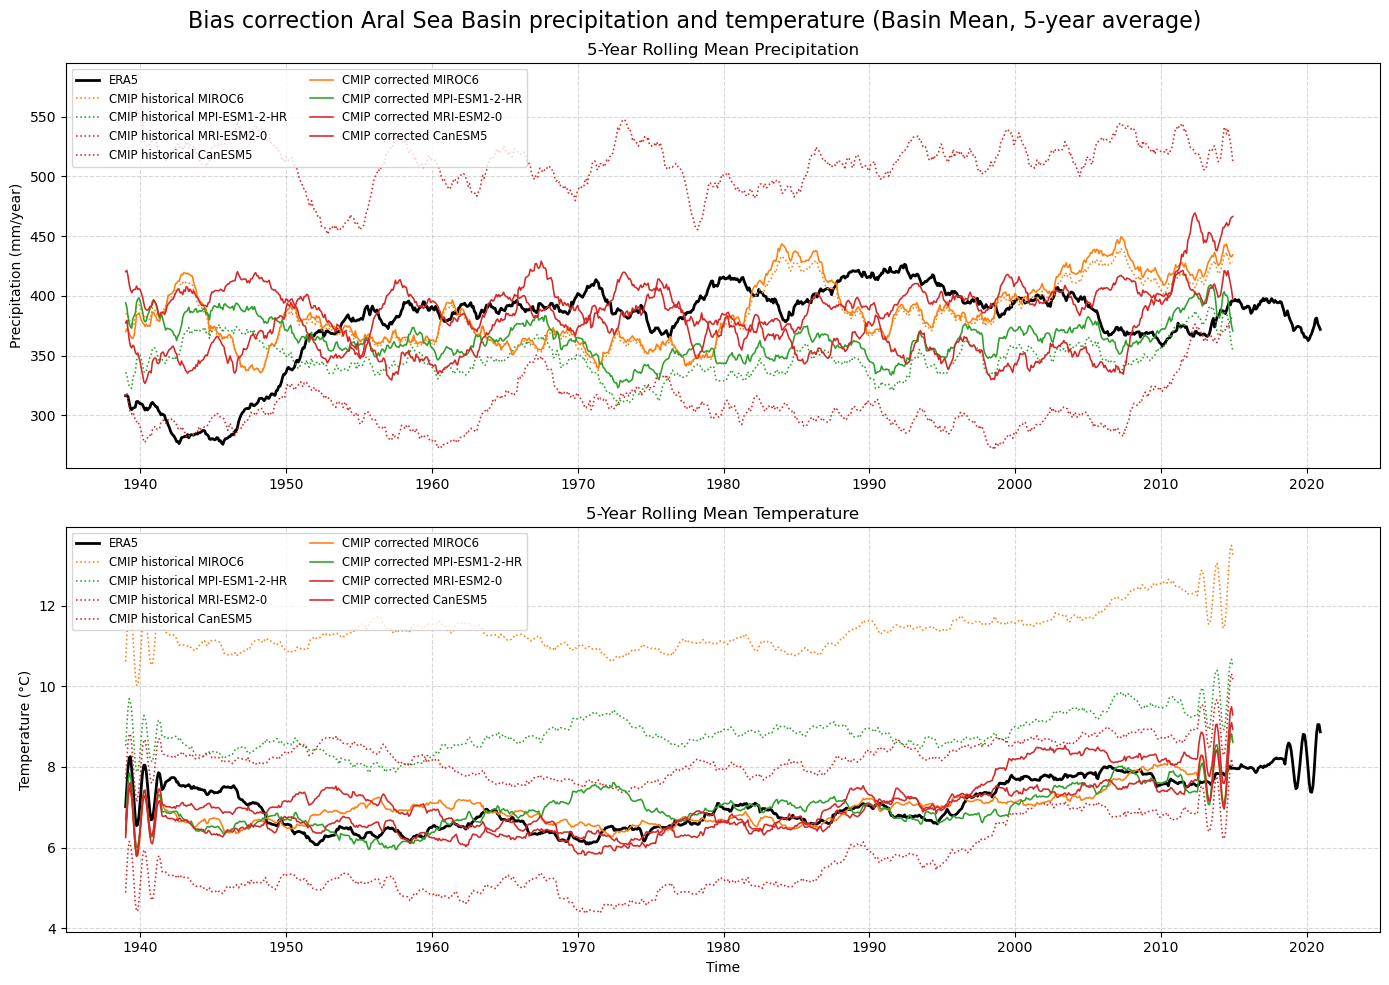

In [17]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

# Plot Precipitation
for name, cfg in experiments.items():
    # PULL DIRECTLY FROM THE COMPUTED DICTIONARY (No .compute() here!)
    pr_series = pr_computed[name] 
    ax1.plot(
        pr_series["time"],
        pr_series,
        color=cfg["color"],
        linewidth=cfg["linewidth"],
        linestyle=cfg["linestyle"],
        label=name,
    )

ax1.set_ylabel("Precipitation (mm/year)")
ax1.set_title(f"{window_size_years}-Year Rolling Mean Precipitation")
ax1.legend(loc="upper left", fontsize="small", ncol=2)
ax1.grid(linestyle='--', alpha=0.5)

# Plot Temperature
for name, cfg in experiments.items():
    # PULL DIRECTLY FROM THE COMPUTED DICTIONARY (No .compute() here!)
    tas_series = tas_computed[name] 
    ax2.plot(
        tas_series["time"],
        tas_series,
        color=cfg["color"],
        linewidth=cfg["linewidth"],
        linestyle=cfg["linestyle"],
        label=name,
    )

ax2.set_xlabel("Time")
ax2.set_ylabel("Temperature (°C)")
ax2.set_title(f"{window_size_years}-Year Rolling Mean Temperature")
ax2.legend(loc="upper left", fontsize="small", ncol=2)
ax2.grid(linestyle='--', alpha=0.5)

suptitle = f"Bias correction Aral Sea Basin precipitation and temperature (Basin Mean, {window_size_years}-year average)"
fig.suptitle(suptitle, fontsize=16)
plt.tight_layout()
plt.show()

## Check error

In [18]:
def yearly_temp(ds, var="tas"):
    da = ds[var]
    spatial = [d for d in da.dims if d != "time"]

    if spatial:
        da = da.mean(dim=spatial)

    return da.resample(time="1YS").mean()

def yearly_precip(ds, var="pr"):
    da = ds[var]
    spatial = [d for d in da.dims if d != "time"]

    if spatial:
        da = da.mean(dim=spatial)

    return da.resample(time="1YS").sum()*1000

def select_period(da):
    return da.sel(time=slice("1940-01-01", "2014-12-31"))

def stats(da):
    return {
        "mean": float(da.mean().compute()),
        "std": float(da.std().compute())
    }

In [19]:
# datasets = {
#     "ERA5": load_precip,
#     "CMIP raw": load_cmip_pr,
#     "CMIP bias corrected": load_cmip_hist_bias_pr,
# }

results_pr = {}
results_tas = {}

# `datasets` was changed to hold dicts with 'pr_ds' and 'tas_ds'.
# Use `experiments` which already maps experiment names to those datasets.
for name, cfg in experiments.items():
    pr_ds = cfg['pr_ds']
    tas_ds = cfg['tas_ds']

    pr_year = yearly_precip(pr_ds)
    pr_year = select_period(pr_year)
    results_pr[name] = stats(pr_year)

    tas_year = yearly_temp(tas_ds)
    tas_year = select_period(tas_year)
    results_tas[name] = stats(tas_year)



In [20]:
print("PRECIPITATION (1940–2014)")
for k, v in results_pr.items():
    print(k, v)

print("\nTEMPERATURE (1940–2014)")
for k, v in results_tas.items():
    print(k, v)

PRECIPITATION (1940–2014)
ERA5 {'mean': 377.06610107421875, 'std': 45.622779846191406}
CMIP historical MIROC6 {'mean': 382.18475341796875, 'std': 44.78585433959961}
CMIP historical MPI-ESM1-2-HR {'mean': 346.3090515136719, 'std': 36.63166046142578}
CMIP historical MRI-ESM2-0 {'mean': 510.83453369140625, 'std': 49.94119644165039}
CMIP historical CanESM5 {'mean': 306.6996154785156, 'std': 43.59547424316406}
CMIP corrected MIROC6 {'mean': 386.1806945800781, 'std': 48.863887786865234}
CMIP corrected MPI-ESM1-2-HR {'mean': 362.4078674316406, 'std': 38.135581970214844}
CMIP corrected MRI-ESM2-0 {'mean': 392.52227783203125, 'std': 41.39470291137695}
CMIP corrected CanESM5 {'mean': 371.0317687988281, 'std': 59.545867919921875}

TEMPERATURE (1940–2014)
ERA5 {'mean': 280.17388916015625, 'std': 0.7426552772521973}
CMIP historical MIROC6 {'mean': 284.6064453125, 'std': 0.6719115972518921}
CMIP historical MPI-ESM1-2-HR {'mean': 282.04217529296875, 'std': 0.6376540660858154}
CMIP historical MRI-ESM2

In [ ]:
# # Build a table for multiple CMIP models (and ERA5) and output LaTeX
# import pandas as pd



# def clean_name(name):
#     if name == "ERA5":
#         return ("ERA5", "")

#     if "historical" in name:
#         model = name.replace("CMIP historical ", "")
#         return (model, "Raw")

#     if "corrected" in name:
#         model = name.replace("CMIP corrected ", "")
#         return (model, "Corrected")

#     return (name, "")




# # select experiments to include: ERA5 plus any CMIP entries
# selected = [name for name in experiments.keys() if name == 'ERA5' or name.startswith('CMIP')]

# rows = []
# for name in selected:
#     cfg = experiments[name]
#     pr_ds = cfg['pr_ds']
#     tas_ds = cfg['tas_ds']

#     pr_year = yearly_precip(pr_ds)
#     pr_year = select_period(pr_year)
#     pr_stat = stats(pr_year)

#     tas_year = yearly_temp(tas_ds)
#     tas_year = select_period(tas_year)
#     tas_stat = stats(tas_year)

#     rows.append({
#         'Dataset': name,
#         'Precip Mean (mm/yr)': pr_stat['mean'],
#         'Precip Std': pr_stat['std'],
#         'Temp Mean (K)': tas_stat['mean'],
#         'Temp Std': tas_stat['std'],
#     })

# df = pd.DataFrame(rows).set_index('Dataset')
# # compute bias relative to ERA5 means (as percent)
# era5_pr = df.loc['ERA5', 'Precip Mean (mm/yr)'] if 'ERA5' in df.index else None
# era5_tas = df.loc['ERA5', 'Temp Mean (K)'] if 'ERA5' in df.index else None

# if era5_pr is not None and era5_tas is not None:
#     df['Precip Bias (%)'] = (df['Precip Mean (mm/yr)'] - era5_pr) / era5_pr * 100.0
#     df['Temp Bias (%)'] = (df['Temp Mean (K)'] - era5_tas) / era5_tas * 100.0
# else:
#     df['Precip Bias (%)'] = float('nan')
#     df['Temp Bias (%)'] = float('nan')

# # reorder columns
# df = df[['Precip Mean (mm/yr)', 'Precip Std', 'Precip Bias (%)',
#          'Temp Mean (K)', 'Temp Std', 'Temp Bias (%)']]

# pd.set_option('display.float_format', '{:0.3f}'.format)

# tex_out = Path('/home/avandervee3/complete_pcrglob_run/results/climate_stats_1940_2014.tex')
# tex_out.parent.mkdir(parents=True, exist_ok=True)



# # split into structured columns
# df[["Model", "Type"]] = pd.DataFrame(df.index.map(clean_name).tolist(), index=df.index)

# # sort logically: ERA5 first, then by model, then Raw before Corrected
# df["sort_type"] = df["Type"].map({"Raw": 0, "Corrected": 1, "": -1})

# df = df.sort_values(by=["Model", "sort_type"])

# # rebuild display name
# df["Dataset"] = df.apply(
#     lambda r: r["Model"] if r["Type"] == "" else f"{r['Model']} ({r['Type']})",
#     axis=1
# )

# df = df.set_index("Dataset")

# # drop helper columns
# df = df.drop(columns=["Model", "Type", "sort_type"])




# # --- only export table BODY (no header) ---
# body = df.to_latex(
#     index=True,
#     header=False,
#     float_format="%.3f",
#     column_format='lrrrrrr',
#     escape=False
# )

# # remove automatically added tabular environment
# body = body.split(r'\midrule')[-1]
# body = body.split(r'\bottomrule')[0]

# # --- build full LaTeX table manually ---
# latex = rf"""
# \begin{{table}}[htbp]
# \centering
# \caption[Bias-correction results]{{Basin-averaged annual precipitation and temperature statistics for ERA5, CMIP raw historical forcing, and bias-corrected CMIP data over 1940--2014. Bias is expressed relative to ERA5.}}
# \label{{tab:climate_stats_1940_2014_combined}}
# \begin{{tabular}}{{lcccccc}}
# \toprule
#  & \multicolumn{{3}}{{c}}{{Precipitation}} & \multicolumn{{3}}{{c}}{{Temperature}} \\
# \cmidrule(lr){{2-4}} \cmidrule(lr){{5-7}}
# Dataset & Mean (mm/yr) & Std & Bias (\%) & Mean (K) & Std & Bias (\%) \\
# \midrule
# {body}
# \bottomrule
# \end{{tabular}}
# \end{{table}}
# """

# with open(tex_out, "w") as f:
#     f.write(latex)

# print(f"Wrote LaTeX table to: {tex_out}")


In [22]:
import pandas as pd
from pathlib import Path
from collections import defaultdict

# ------------------------------------------------------------
# 1. Helper: parse dataset names
# ------------------------------------------------------------
def clean_name(name):
    if name == "ERA5":
        return ("ERA5", "")

    if "historical" in name:
        model = name.replace("CMIP historical ", "")
        return (model, "Raw")

    if "corrected" in name:
        model = name.replace("CMIP corrected ", "")
        return (model, "Corrected")

    return (name, "")


# ------------------------------------------------------------
# 2. Build dataset table
# ------------------------------------------------------------
selected = [name for name in experiments.keys()
            if name == 'ERA5' or name.startswith('CMIP')]

rows = []

for name in selected:
    cfg = experiments[name]

    pr_ds = cfg['pr_ds']
    tas_ds = cfg['tas_ds']

    pr_year = yearly_precip(pr_ds)
    pr_year = select_period(pr_year)
    pr_stat = stats(pr_year)

    tas_year = yearly_temp(tas_ds)
    tas_year = select_period(tas_year)
    tas_stat = stats(tas_year)

    rows.append({
        'Dataset': name,
        'Precip Mean (mm/yr)': pr_stat['mean'],
        'Precip Std': pr_stat['std'],
        'Temp Mean (K)': tas_stat['mean'],
        'Temp Std': tas_stat['std'],
    })

df = pd.DataFrame(rows).set_index('Dataset')


# ------------------------------------------------------------
# 3. Bias relative to ERA5
# ------------------------------------------------------------
era5_pr = df.loc['ERA5', 'Precip Mean (mm/yr)']
era5_tas = df.loc['ERA5', 'Temp Mean (K)']

df['Precip Bias (%)'] = (df['Precip Mean (mm/yr)'] - era5_pr) / era5_pr * 100
df['Temp Bias (%)'] = (df['Temp Mean (K)'] - era5_tas) / era5_tas * 100


# ------------------------------------------------------------
# 4. Reorder columns
# ------------------------------------------------------------
df = df[['Precip Mean (mm/yr)', 'Precip Std', 'Precip Bias (%)',
         'Temp Mean (K)', 'Temp Std', 'Temp Bias (%)']]


# ------------------------------------------------------------
# 5. Build hierarchy (Model + Raw/Corrected)
# ------------------------------------------------------------
df[["Model", "Type"]] = pd.DataFrame(
    df.index.map(clean_name).tolist(),
    index=df.index
)

df["sort_type"] = df["Type"].map({"Raw": 0, "Corrected": 1, "": -1})
df = df.sort_values(["Model", "sort_type"])


# ------------------------------------------------------------
# 6. Group for hierarchical LaTeX
# ------------------------------------------------------------
groups = defaultdict(list)

for idx, row in df.iterrows():
    groups[row["Model"]].append((idx, row))


# ------------------------------------------------------------
# 7. Build LaTeX body (multirow structure)
# ------------------------------------------------------------
lines = []

first_block = True

for model, items in groups.items():

    # -------------------------------------------------
    # ERA5 block (no multirow)
    # -------------------------------------------------
    if model == "ERA5":

        if not first_block:
            lines.append(r"\midrule")

        idx, r = items[0]

        # lines.append(
        #     f"{model} & & "
        #     f"{r['Precip Mean (mm/yr)']:.3f} & {r['Precip Std']:.3f} & {r['Precip Bias (%)']:.3f} & "
        #     f"{r['Temp Mean (K)']:.3f} & {r['Temp Std']:.3f} & {r['Temp Bias (%)']:.3f} \\\\"
        # )
        lines.append(
            f"{model} & Reference & "
            f"{r['Precip Mean (mm/yr)']:.3f} & {r['Precip Std']:.3f} & - & "
            f"{r['Temp Mean (K)']:.3f} & {r['Temp Std']:.3f} & - \\\\"
        )


        first_block = False
        continue

    # -------------------------------------------------
    # CMIP model blocks
    # -------------------------------------------------
    if not first_block:
        lines.append(r"\midrule")   # <<< RULE ABOVE EACH BLOCK

    n = len(items)
    first = True

    for idx, r in items:

        model_cell = f"\\multirow{{{n}}}{{*}}{{{model}}}" if first else ""

        lines.append(
            f"{model_cell} & {r['Type']} & "
            f"{r['Precip Mean (mm/yr)']:.3f} & {r['Precip Std']:.3f} & {r['Precip Bias (%)']:.3f} & "
            f"{r['Temp Mean (K)']:.3f} & {r['Temp Std']:.3f} & {r['Temp Bias (%)']:.3f} \\\\"
        )

        first = False

    first_block = False
    
    

body = "\n".join(lines)


# ------------------------------------------------------------
# 8. Output path
# ------------------------------------------------------------
tex_out = Path(
    "/home/avandervee3/aral_sea_full_project/scripts/climate_stats_1940_2014.tex"
)
tex_out.parent.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 9. Final LaTeX table
# ------------------------------------------------------------
latex = rf"""
\begin{{table}}[htbp]
\centering
\caption[Bias-correction results]{{Basin-averaged annual precipitation and temperature statistics for ERA5, CMIP raw historical forcing, and bias-corrected CMIP data over 1940--2014. Bias is expressed relative to ERA5, which are used as pseudo-observations in this study.}}
\label{{tab:climate_stats_1940_2014_combined_v2}}
\begin{{tabular}}{{llrrrrrr}}
\toprule
 &  & \multicolumn{{3}}{{c}}{{Precipitation}} & \multicolumn{{3}}{{c}}{{Temperature}} \\
\cmidrule(lr){{3-5}} \cmidrule(lr){{6-8}}
Dataset & Type & Mean (mm/yr) & Std & Bias (\%) & Mean (K) & Std & Bias (\%) \\
\midrule
{body}
\bottomrule
\end{{tabular}}
\end{{table}}
"""


# ------------------------------------------------------------
# 10. Write file
# ------------------------------------------------------------
with open(tex_out, "w") as f:
    f.write(latex)

print(f"Wrote LaTeX table to: {tex_out}")

KeyboardInterrupt: 

In [24]:
import pandas as pd
from pathlib import Path
from collections import defaultdict

# ------------------------------------------------------------
# 1. Helper: parse dataset names
# ------------------------------------------------------------
def clean_name(name):
    if name == "ERA5":
        return ("ERA5", "")

    if "historical" in name:
        model = name.replace("CMIP historical ", "")
        return (model, "Raw")

    if "corrected" in name:
        model = name.replace("CMIP corrected ", "")
        return (model, "Corrected")

    return (name, "")

# ------------------------------------------------------------
# 2. Build dataset table DIRECTLY from your pre-calculated dicts
# ------------------------------------------------------------
rows = []

for name in results_pr.keys():
    pr_stat = results_pr[name]
    tas_stat = results_tas[name]

    rows.append({
        'Dataset': name,
        'Precip Mean (mm/yr)': pr_stat['mean'],
        'Precip Std': pr_stat['std'],
        'Temp Mean (K)': tas_stat['mean'],
        'Temp Std': tas_stat['std'],
    })

df = pd.DataFrame(rows).set_index('Dataset')

# ------------------------------------------------------------
# 3. Bias relative to ERA5
# ------------------------------------------------------------
era5_pr = df.loc['ERA5', 'Precip Mean (mm/yr)']
era5_tas = df.loc['ERA5', 'Temp Mean (K)']

df['Precip Bias (%)'] = (df['Precip Mean (mm/yr)'] - era5_pr) / era5_pr * 100
df['Temp Bias (%)'] = (df['Temp Mean (K)'] - era5_tas) / era5_tas * 100

# ------------------------------------------------------------
# 4. Reorder columns
# ------------------------------------------------------------
df = df[['Precip Mean (mm/yr)', 'Precip Std', 'Precip Bias (%)',
         'Temp Mean (K)', 'Temp Std', 'Temp Bias (%)']]

# ------------------------------------------------------------
# 5. Build hierarchy (Model + Raw/Corrected) and enforce ERA5 on top
# ------------------------------------------------------------
df[["Model", "Type"]] = pd.DataFrame(
    df.index.map(clean_name).tolist(),
    index=df.index
)

# Use an explicit sort key to force ERA5 up front, followed by alphabetical models
df["sort_model"] = df["Model"].apply(lambda x: "00_ERA5" if x == "ERA5" else f"01_{x}")
df["sort_type"] = df["Type"].map({"Raw": 0, "Corrected": 1, "": -1})
df = df.sort_values(["sort_model", "sort_type"])

# ------------------------------------------------------------
# 6. Group for hierarchical LaTeX (Preserving the ordered rows)
# ------------------------------------------------------------
groups = defaultdict(list)

for idx, row in df.iterrows():
    groups[row["Model"]].append((idx, row))

# ------------------------------------------------------------
# 7. Build LaTeX body (multirow structure)
# ------------------------------------------------------------
lines = []
first_block = True

# We loop specifically over the sorted models to keep ERA5 strictly first
unique_models_sorted = df["Model"].unique()

for model in unique_models_sorted:
    items = groups[model]

    # -------------------------------------------------
    # ERA5 block (no multirow)
    # -------------------------------------------------
    if model == "ERA5":
        idx, r = items[0]
        lines.append(
            f"{model} & Reference & "
            f"{r['Precip Mean (mm/yr)']:.3f} & {r['Precip Std']:.3f} & - & "
            f"{r['Temp Mean (K)']:.3f} & {r['Temp Std']:.3f} & - \\\\"
        )
        first_block = False
        continue

    # -------------------------------------------------
    # CMIP model blocks
    # -------------------------------------------------
    if not first_block:
        lines.append(r"\midrule")

    n = len(items)
    first = True

    for idx, r in items:
        model_cell = f"\\multirow{{{n}}}{{*}}{{{model}}}" if first else ""

        lines.append(
            f"{model_cell} & {r['Type']} & "
            f"{r['Precip Mean (mm/yr)']:.3f} & {r['Precip Std']:.3f} & {r['Precip Bias (%)']:.3f} & "
            f"{r['Temp Mean (K)']:.3f} & {r['Temp Std']:.3f} & {r['Temp Bias (%)']:.3f} \\\\"
        )
        first = False

    first_block = False

body = "\n".join(lines)

# ------------------------------------------------------------
# 8. Output path
# ------------------------------------------------------------
tex_out = Path(
    "/home/avandervee3/aral_sea_full_project/scripts/climate_stats_1940_2014.tex"
)
tex_out.parent.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 9. Final LaTeX table
# ------------------------------------------------------------
latex = rf"""
\begin{{table}}[htbp]
\centering
\caption[Bias-correction results]{{Basin-averaged annual precipitation and temperature statistics for ERA5, CMIP raw historical forcing, and bias-corrected CMIP data over 1940--2014. Bias is expressed relative to ERA5, which are used as pseudo-observations in this study.}}
\label{{tab:climate_stats_1940_2014_combined_v2}}
\begin{{tabular}}{{llrrrrrr}}
\toprule
 &  & \multicolumn{{3}}{{c}}{{Precipitation}} & \multicolumn{{3}}{{c}}{{Temperature}} \\
\cmidrule(lr){{3-5}} \cmidrule(lr){{6-8}}
Dataset & Type & Mean (mm/yr) & Std & Bias (\%) & Mean (K) & Std & Bias (\%) \\
\midrule
{body}
\bottomrule
\end{{tabular}}
\end{{table}}
"""

# ------------------------------------------------------------
# 10. Write file
# ------------------------------------------------------------
with open(tex_out, "w") as f:
    f.write(latex)

print(f"Wrote LaTeX table to: {tex_out}")

Wrote LaTeX table to: /home/avandervee3/aral_sea_full_project/scripts/climate_stats_1940_2014.tex
